In [1]:
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, precision_score, recall_score, confusion_matrix
sns.set(style="whitegrid")  # clean charts
pd.options.display.float_format = '{:.2f}'.format

In [2]:
df = pd.read_csv("credit_card_transactions.csv").sort_values("trans_date_trans_time")

In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   1296675 non

In [4]:
# Ensure datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['date'] = df['trans_date_trans_time'].dt.date
df['hour'] = df['trans_date_trans_time'].dt.hour
# print(df.info())

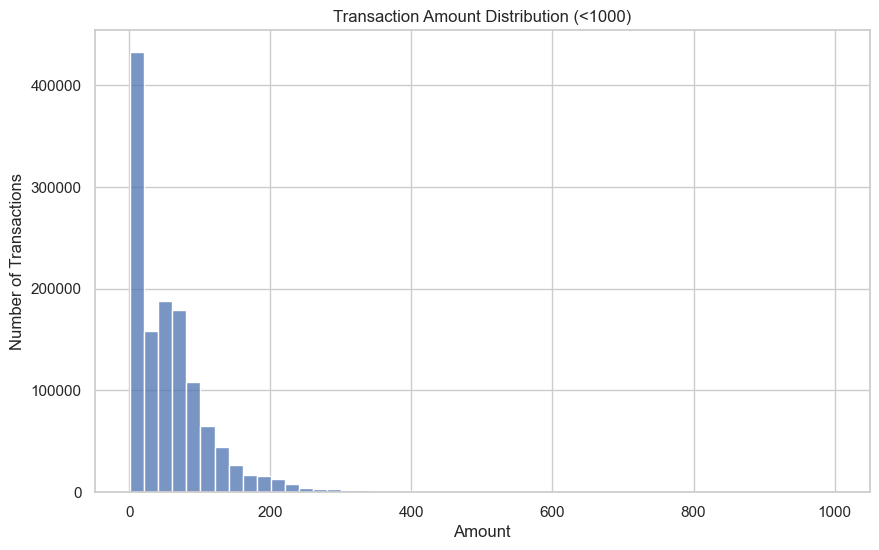

In [5]:
# Transaction amount distribution (<1000 to remove outliers)
plt.figure(figsize=(10,6))
sns.histplot(df[df['amt']<1000]['amt'], bins=50, kde=False)
plt.title("Transaction Amount Distribution (<1000)")
plt.xlabel("Amount")
plt.ylabel("Number of Transactions")
plt.show()


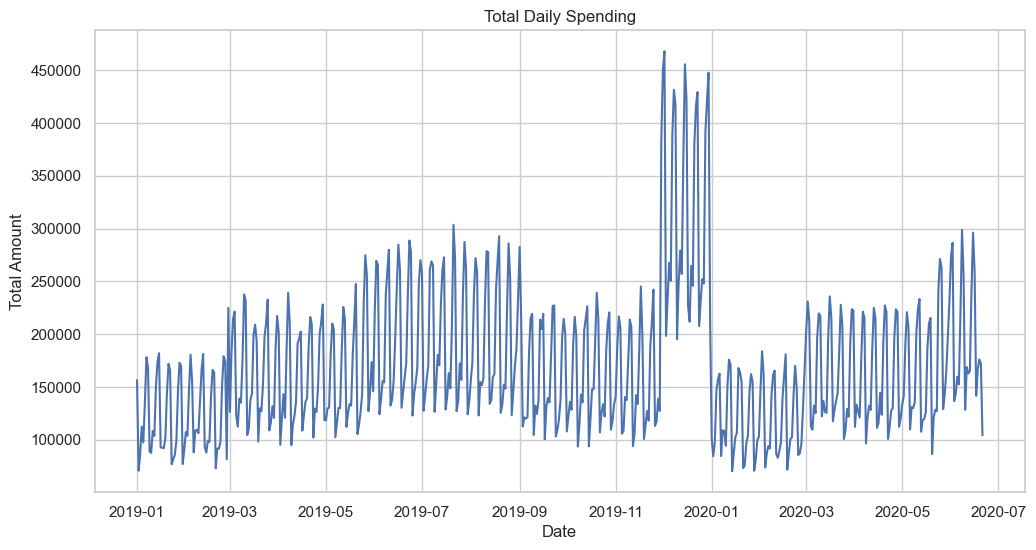

In [6]:
# Daily total spending
daily_spending = df.groupby('date')['amt'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=daily_spending, x='date', y='amt')
plt.title("Total Daily Spending")
plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.show()


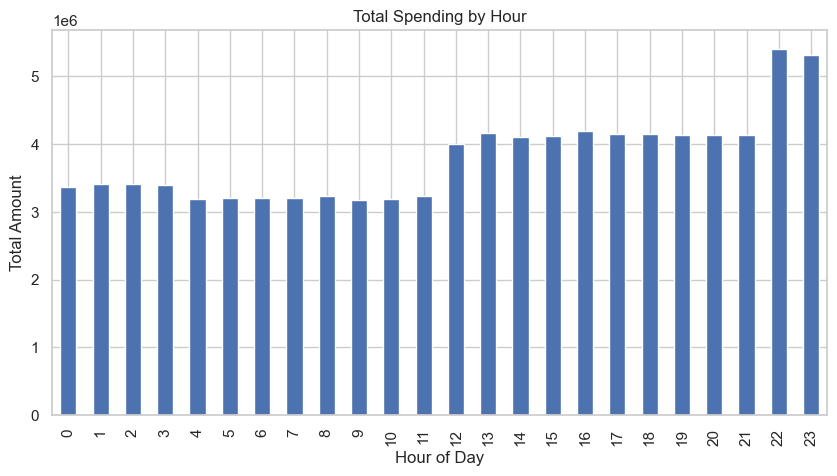

In [7]:
# Hourly spending
hourly_spending = df.groupby('hour')['amt'].sum()
plt.figure(figsize=(10,5))
hourly_spending.plot(kind='bar')
plt.title("Total Spending by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Total Amount")
plt.show()


In [8]:
# Customer Aggregation
customer_summary = df.groupby("cc_num", as_index=False).agg(
    avg_amt=("amt", "mean"),
    total_amt=("amt", "sum"),
    txn_count=("amt", "count")
)
#customer_summary

In [9]:
# Transactions per day for frequency
daily_txn = df.groupby(["cc_num","date"]).size().reset_index(name="txn_per_day")
frequency = daily_txn.groupby("cc_num")["txn_per_day"].mean().reset_index(name="avg_txn_per_day")

final_table = customer_summary.merge(frequency, on="cc_num")
final_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 983 entries, 0 to 982
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cc_num           983 non-null    int64  
 1   avg_amt          983 non-null    float64
 2   total_amt        983 non-null    float64
 3   txn_count        983 non-null    int64  
 4   avg_txn_per_day  983 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 38.5 KB


In [10]:
# Spending segment
final_table['spender_segment'] = pd.qcut(
    final_table['total_amt'], 3, labels=['Low','Medium','High']
)


In [11]:
# Transaction frequency segment
final_table['txn_segment'] = pd.qcut(
    final_table['txn_count'], 3, labels=['Occasional','Regular','Frequent']
)
#final_table.info()

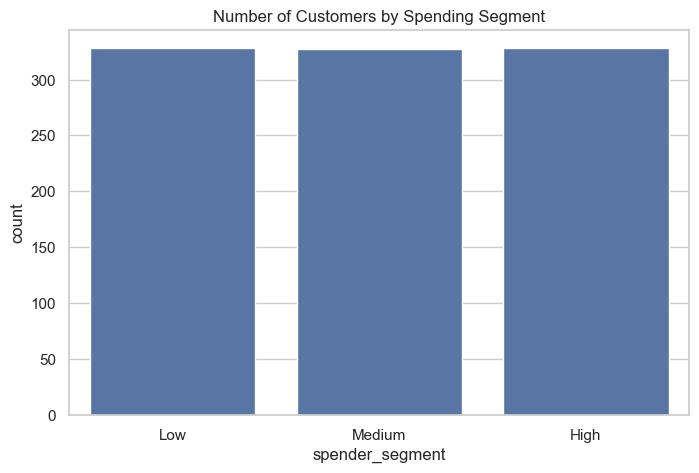

In [12]:
# Visualize
plt.figure(figsize=(8,5))
sns.countplot(data=final_table, x='spender_segment')
plt.title("Number of Customers by Spending Segment")
plt.show()

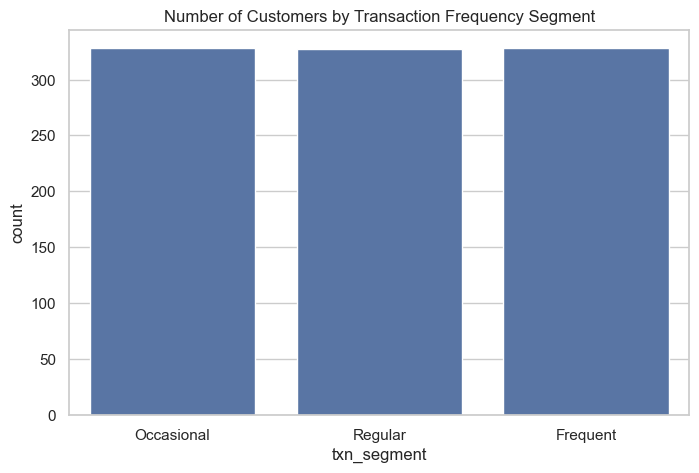

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=final_table, x='txn_segment')
plt.title("Number of Customers by Transaction Frequency Segment")
plt.show()

In [14]:
# Prepare data for heatmap
segment_summary = final_table.groupby(['spender_segment','txn_segment']).size().reset_index(name='count')
segment_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   spender_segment  7 non-null      category
 1   txn_segment      7 non-null      category
 2   count            7 non-null      int64   
dtypes: category(2), int64(1)
memory usage: 504.0 bytes


In [15]:
# Pivot using keywords
heatmap_data = segment_summary.pivot(
    index='spender_segment',
    columns='txn_segment',
    values='count'
).fillna(0)
heatmap_data = heatmap_data.astype(int)
segment_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   spender_segment  7 non-null      category
 1   txn_segment      7 non-null      category
 2   count            7 non-null      int64   
dtypes: category(2), int64(1)
memory usage: 504.0 bytes


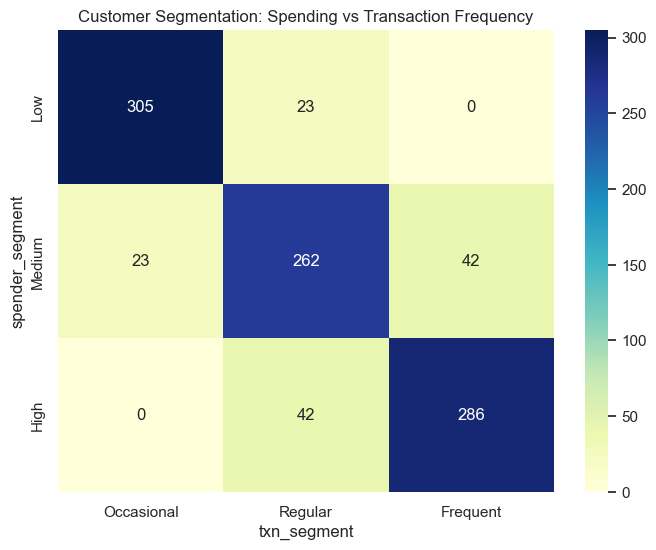

In [16]:
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap="YlGnBu")
plt.title("Customer Segmentation: Spending vs Transaction Frequency")
plt.show()

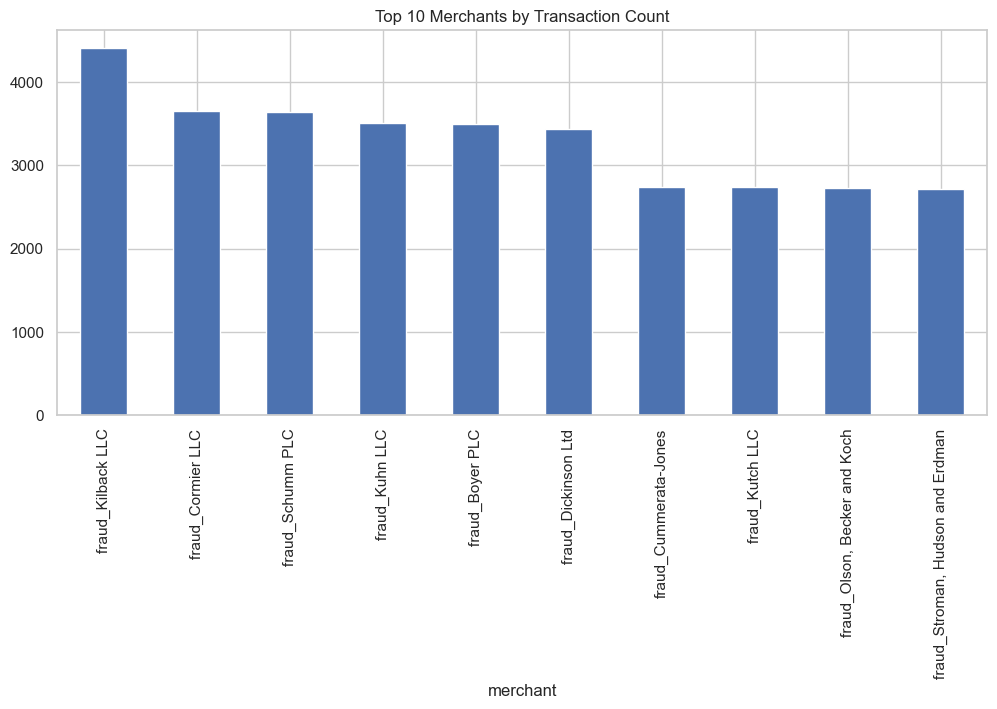

In [17]:
# Top 10 merchants by transaction count
top_merchants = df['merchant'].value_counts().head(10)
top_merchants.plot(kind='bar', figsize=(12,5))
plt.title("Top 10 Merchants by Transaction Count")
plt.show()





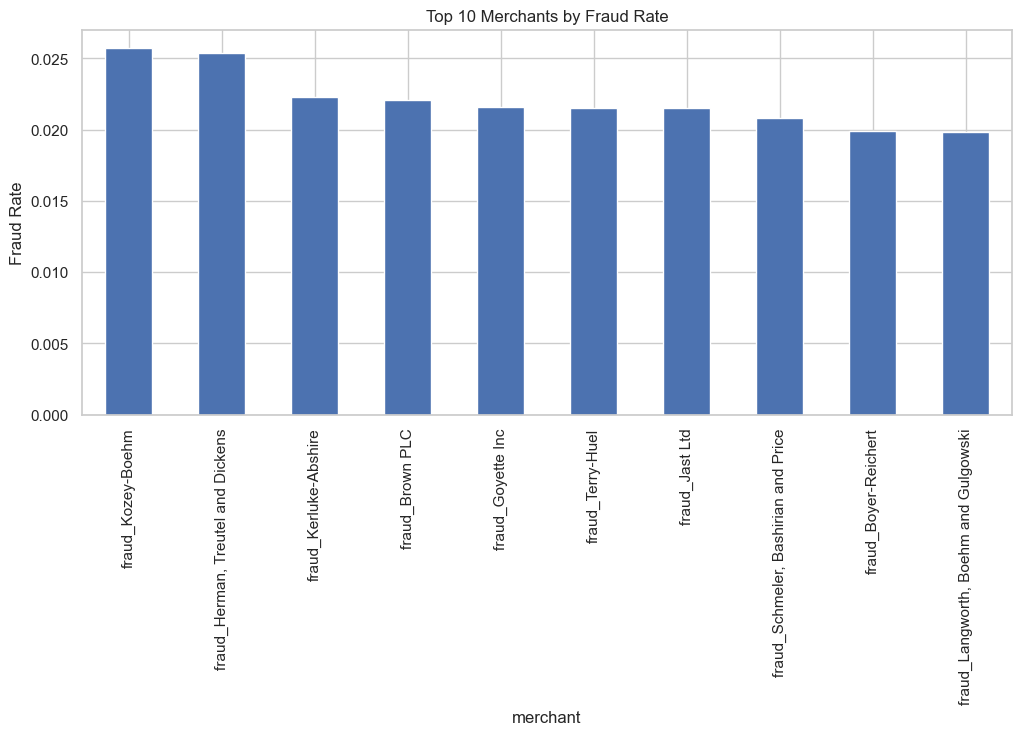

In [18]:
# Top 10 merchants by fraud rate
merchant_fraud = df.groupby('merchant')['is_fraud'].mean().sort_values(ascending=False).head(10)
merchant_fraud.plot(kind='bar', figsize=(12,5))
plt.title("Top 10 Merchants by Fraud Rate")
plt.ylabel("Fraud Rate")
plt.show()

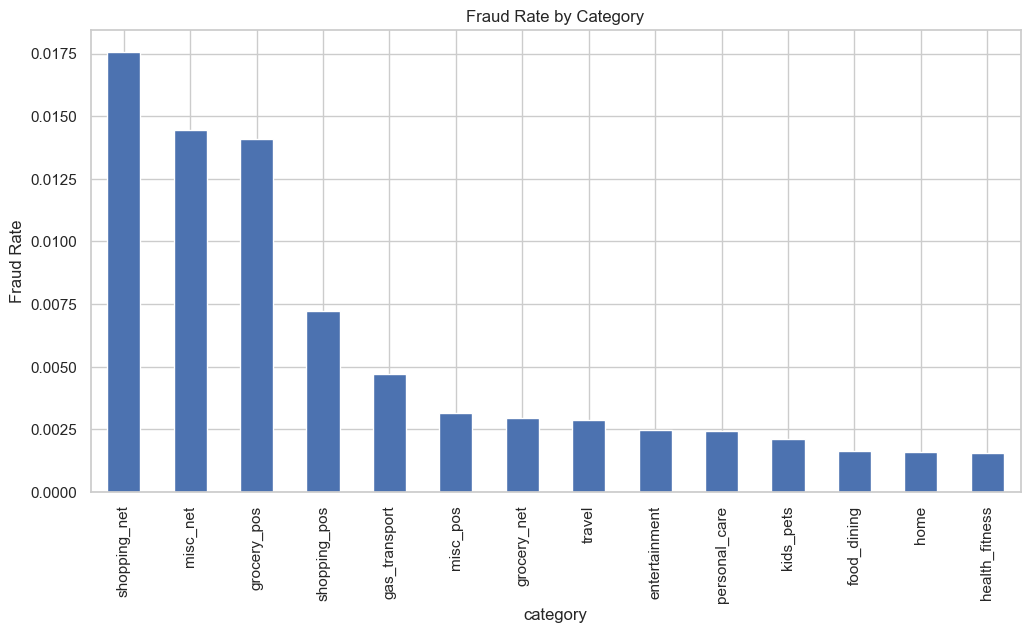

In [19]:
# Fraud by category
category_fraud = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
category_fraud.plot(kind='bar')
plt.title("Fraud Rate by Category")
plt.ylabel("Fraud Rate")
plt.show()


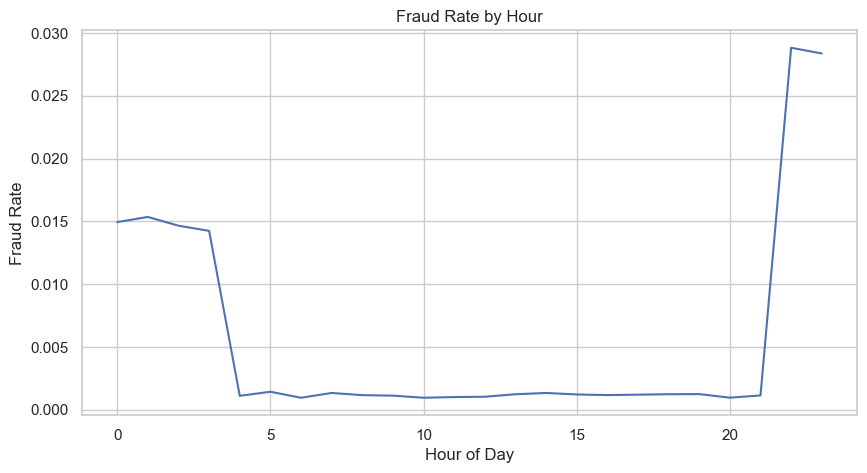

In [20]:
#Time-Based Fraud Insights
fraud_by_hour = df.groupby('hour')['is_fraud'].mean()
plt.figure(figsize=(10,5))
fraud_by_hour.plot()
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.show()

In [21]:
# High-risk hours (22:00-03:00)
df['high_risk_hour'] = df['hour'].apply(lambda x: 1 if (x >=22 or x <=3) else 0)
high_risk_fraud = df.groupby('high_risk_hour')['is_fraud'].mean()
print("Fraud rate by high-risk hour flag:\n", high_risk_fraud)

Fraud rate by high-risk hour flag:
 high_risk_hour
0   0.00
1   0.02
Name: is_fraud, dtype: float64


In [22]:

# -------------------------------
# 7️⃣ Rule-Based Fraud Detection
# -------------------------------

# 7.1 Large transaction detection (95th percentile)
threshold_large = df['amt'].quantile(0.95)
df['large_txn_flag'] = df['amt'].apply(lambda x: 1 if x > threshold_large else 0)



In [23]:
# 7.2 High-frequency transactions (per day per customer)
freq_threshold = daily_txn['txn_per_day'].quantile(0.95)
daily_txn['high_freq_flag'] = daily_txn['txn_per_day'].apply(lambda x: 1 if x > freq_threshold else 0)
df = df.merge(daily_txn[['cc_num','date','high_freq_flag']], on=['cc_num','date'], how='left')
df.head()


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,date,hour,high_risk_hour,large_txn_flag,high_freq_flag
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,1325376018,36.01,-82.05,0,28705.00,2019-01-01,0,1,0,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,1325376044,49.16,-118.19,0,NaN,2019-01-01,0,1,0,1
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,1325376051,43.15,-112.15,0,83236.00,2019-01-01,0,1,1,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,1325376076,47.03,-112.56,0,NaN,2019-01-01,0,1,0,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,1325376186,38.67,-78.63,0,22844.00,2019-01-01,0,1,0,0


In [24]:
# 7.3 Unusual time activity
df['unusual_time_flag'] = df['hour'].apply(lambda x: 1 if (x >=22 or x <=3) else 0)

# 7.4 Location anomaly (distance >100 km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
df['location_flag'] = df['distance_km'].apply(lambda x: 1 if x>100 else 0)


In [25]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode', 'date', 'hour',
       'high_risk_hour', 'large_txn_flag', 'high_freq_flag',
       'unusual_time_flag', 'distance_km', 'location_flag'],
      dtype='str')

In [26]:
# 7.5 Risk scoring
df['risk_score'] = (
    df['large_txn_flag'] +
    df['high_freq_flag'] +
    df['unusual_time_flag'] +
    df['location_flag']
)
df['risk_score_pct'] = df['risk_score']/4*100



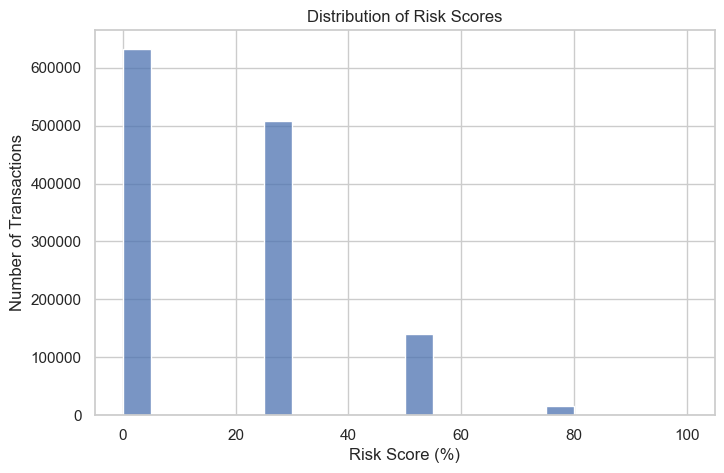

In [27]:
# Histogram of risk scores
plt.figure(figsize=(8,5))
sns.histplot(df['risk_score_pct'], bins=20)
plt.title("Distribution of Risk Scores")
plt.xlabel("Risk Score (%)")
plt.ylabel("Number of Transactions")
plt.show()

In [28]:
# Fraud rate by risk score
print(df.groupby('risk_score')['is_fraud'].mean())

risk_score
0   0.00
1   0.00
2   0.03
3   0.10
4   0.22
Name: is_fraud, dtype: float64


In [29]:
# Location anomaly (distance >100 km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2*R*np.arcsin(np.sqrt(a))



In [30]:
distance = haversine(40.7128, -74.0060, 51.5074, -0.1278)
print(distance)

5570.222179737958


In [31]:
print(haversine(10, 20, 10, 20))

0.0


In [32]:
drop_cols = [
    'Unnamed: 0',
    'cc_num',          # unique ID → leakage risk
    'first', 'last',   # personal info (not useful)
    'street', 'zip',
    'trans_num',       # unique transaction ID
    'unix_time',       # duplicate of datetime
    'date',            # redundant
]
df.drop(columns = drop_cols, inplace = True)

In [33]:
features = [
    'amt',
    'city_pop',
    'lat', 'long',
    'merch_lat', 'merch_long',
    'category',
    'gender',
    'job',

    # engineered features (VERY GOOD)
    'hour',
    'high_risk_hour',
    'large_txn_flag',
    'high_freq_flag',
    'unusual_time_flag',
    'distance_km',
    'location_flag',
    'risk_score_pct'
]

In [37]:
df.head()

,trans_date_trans_time,merchant,category,amt,gender,city,state,lat,long,city_pop,...,merch_zipcode,hour,high_risk_hour,large_txn_flag,high_freq_flag,unusual_time_flag,distance_km,location_flag,risk_score,risk_score_pct
0,2019-01-01 00:00:18,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,36.08,-81.18,3495,...,28705.00,0,1,0,0,1,78.60,0,1,25.00
1,2019-01-01 00:00:44,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,48.89,-118.21,149,...,NaN,0,1,0,1,1,30.21,0,2,50.00
2,2019-01-01 00:00:51,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,42.18,-112.26,4154,...,83236.00,0,1,1,0,1,108.21,1,3,75.00
3,2019-01-01 00:01:16,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,46.23,-112.11,1939,...,NaN,0,1,0,0,1,95.67,0,1,25.00
4,2019-01-01 00:03:06,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,38.42,-79.46,99,...,22844.00,0,1,0,0,1,77.56,0,1,25.00


In [35]:
df_clean.head()

NameError: name 'df_clean' is not defined

In [34]:
df_clean['dob'] = df['dob']

NameError: name 'df_clean' is not defined

In [ ]:
df_clean['trans_date_trans_time'] = df['trans_date_trans_time']

In [38]:
df['age'] = (
    df['trans_date_trans_time'].dt.year -
    df['dob'].dt.year
)


In [39]:
features.append('age')

In [40]:
categorical_cols = ['category', 'gender', 'job']

In [41]:
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [42]:
split_date = df['trans_date_trans_time'].quantile(0.80)

train_df = df[df['trans_date_trans_time'] < split_date]
test_df  = df[df['trans_date_trans_time'] >= split_date]

In [43]:
X_train = train_df[features].copy()
y_train = train_df['is_fraud']

X_test = test_df[features].copy()
y_test = test_df['is_fraud']

In [44]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    enable_categorical=True,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [45]:
y_probs = model.predict_proba(X_test)[:, 1]

BEST_THRESHOLD = 0.2
y_pred = (y_probs >= BEST_THRESHOLD).astype(int)
y_pred[:5]

array([0, 0, 0, 0, 0])

In [46]:
auprc = average_precision_score(y_test, y_probs)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr = fp / (fp + tn)

print("=== FINAL MODEL ===")
print(f"AUPRC: {auprc:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"FPR: {fpr:.4f}")

=== FINAL MODEL ===
AUPRC: 0.645
Precision: 0.244
Recall: 0.806
FPR: 0.0149


In [47]:
def decision(prob):
    if prob >= 0.8:
        return "BLOCK"
    elif prob >= 0.2:
        return "FLAG"
    else:
        return "APPROVE"

test_df['decision'] = [decision(p) for p in y_probs]

In [53]:
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)

In [50]:

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': model.feature_names_in_,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.to_csv('feature_importance.csv', index=False)


In [69]:
# STEP 0: Ensure y_probs is 1D
y_probs = model.predict_proba(X_test)[:, 1]  # only class 1 probability

# STEP 1: Build prediction dataframe
pred_df = X_test.copy()
pred_df['Actual'] = y_test
pred_df['Predicted'] = (y_probs >= BEST_THRESHOLD).astype(int)
pred_df['Probability'] = y_probs  # now 1D, safe

# STEP 2: Re-attach datetime
pred_df['trans_date_trans_time'] = df.loc[X_test.index, 'trans_date_trans_time'].values

In [70]:
print(pred_df[['trans_date_trans_time']].head())

        trans_date_trans_time
1037340   2020-03-06 07:16:43
1037341   2020-03-06 07:18:00
1037342   2020-03-06 07:19:45
1037343   2020-03-06 07:21:19
1037344   2020-03-06 07:21:23


In [72]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender',
       'city', 'state', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'merch_zipcode', 'hour', 'high_risk_hour',
       'large_txn_flag', 'high_freq_flag', 'unusual_time_flag', 'distance_km',
       'location_flag', 'risk_score', 'risk_score_pct', 'age'],
      dtype='str')

In [73]:
pred_df['trans_date_trans_time'] = pd.to_datetime(pred_df['trans_date_trans_time'])

pred_df['Date'] = pred_df['trans_date_trans_time'].dt.date
pred_df['Month'] = pred_df['trans_date_trans_time'].dt.to_period('M')
pred_df['DayOfWeek'] = pred_df['trans_date_trans_time'].dt.day_name()

In [74]:
agg_df = pred_df.groupby('Date').agg(
    Fraud_Actual=('Actual', 'sum'),
    Fraud_Predicted=('Predicted', 'sum'),
    Total_Transactions=('Actual', 'count')
).reset_index()

agg_df['Fraud_Rate'] = agg_df['Fraud_Actual'] / agg_df['Total_Transactions']

In [67]:
print(type(df.loc[X_test.index, 'trans_date_trans_time']))
print(df.loc[X_test.index, 'trans_date_trans_time'].shape)

<class 'pandas.Series'>
(259335,)


In [75]:
pred_df.to_csv('predictions_full.csv', index=False)
agg_df.to_csv('aggregated.csv', index=False)